# Exploratory Data and RFM Analysis on E-commerce dataset
<!-- <div style="border: 2px solid #5C9AFF; padding: 15px; color: #002047; text-align: center; border-radius: 10px;">
    <h1 style="margin: 0;">Exploratory Data Analysis on E-commerce dataset</h1>
</div> -->

<div style="background-color: #f0f7ff; border-left: 5px solid #5C9AFF; padding: 15px; border-radius: 5px; font-family: 'Roboto', sans-serif;">
    <p style="margin: 0; color: #002047;"><strong>Dataset:</strong> E-commerce dataset</p>
    <p style="margin: 5px 0; color: #002047;"><strong>Source:</strong> <a href="https://www.kaggle.com/datasets/carrie1/ecommerce-data" style="color: #5C9AFF;">Kaggle</a></p>
    <p style="margin: 0; color: #002047;"><strong>Author:</strong> Fishchenko Tamara</p>
</div>


### Styling headers and markdown cells
To improve the document's visual structure and readability, I chose Roboto as my main font, as well as a monochromatic blue gradient to headers.

In [4]:
%%html
<style>
@import url('https://fonts.googleapis.com');
.jp-RenderedHTMLCommon, .text_cell_render { 
    font-family: 'Roboto', sans-serif !important; 
    font-size: 15px !important;
    line-height: 1.6 !important;
}

.jp-RenderedHTMLCommon h1, .jp-RenderedHTMLCommon h2, 
.jp-RenderedHTMLCommon h3, .jp-RenderedHTMLCommon h4 {
    padding: 15px !important;
    border-radius: 8px !important;
    margin-top: 25px !important;
    margin-bottom: 10px !important;
    font-weight: 700 !important;
}

/* # Header 1 */
.jp-RenderedHTMLCommon h1 {
    background-color: #f0f7ff !important;
    border-left: 10px solid #5C9AFF !important;
    color: #002047 !important;
}

/* ## Header 2 */
.jp-RenderedHTMLCommon h2 {
    background-color: #e1ecf7 !important;
    border-left: 10px solid #528ae5 !important;
    color: #003366 !important;
}

/* ### Header 3 */
.jp-RenderedHTMLCommon h3 {
    background-color: #d6e4f2 !important;
    border-left: 10px solid #1e4f9a !important;
    color: #002047 !important;
}

/* #### Header 4 */
.jp-RenderedHTMLCommon h4 {
    background-color: #cbdcf0 !important;
    border-left: 10px solid #002047 !important;
    color: #001530 !important;
}
</style>

### Contents
1. Data loading
2. Data cleaning
   - Duplicates
   - Negative quantities and prices
3. Missing values analysis
4. StockCode analysis
5. Revenue analysis
6. Cancellations analysis
7. RFM preparation

### Objective
The goal of this notebook includes solving following tasks:  
- Data cleaning and validation
- Missing values handling
- Dublicates handling
- Stock code normalization
- Feature engineering
- Outlier detection
- Graphs construction
- RFM analysis preparation and realization

### Expected result

The expected result of this analysis is a cleaned dataset with consistent formats and correct data types and a new set of new engineered features that will be used for further analysis.

## Data preparation and loading

In [9]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from IPython.display import display, HTML
from matplotlib.ticker import FuncFormatter

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 14

BRAND_BLUE = "#69aeff"
TEXT_NAVY = "#000d3f"

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [10]:
# importing raw data
df = pd.read_csv("data.csv", encoding="ISO-8859-1")

In [11]:
# examples of rows of dataset
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.00,United Kingdom


## Data cleaning

### Dataset Description

In [14]:
df.shape

(541909, 8)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


The dataset of e-commerce transactions contains all transactions occurring between 01.12.2010 and 09.12.2011 for a UK-based and registered non-store online retail. The company mainly sells unique all-occasion gifts and many customers of the company are wholesalers. Each row represents one product in an invoice, the same invoice number can appear multiple times when an order contains multiple products.  
There are 541909 rows and 8 columns with their purposes described in the next table.
| Variable      | Description |
|--------------|------------|
| **InvoiceNo** | Code representing each unique transaction. If it starts with *'C'*, it indicates a cancellation. |
| **StockCode** | Unique code assigned to each product. |
| **Description** | Name of the product. |
| **Quantity** | Amount of product purchased. Negative values typically indicate returns or cancellations. |
| **InvoiceDate** | Date and time of the transaction. |
| **UnitPrice** | Price per unit of product (in GBP). |
| **CustomerID** | Unique identifier assigned to each customer. |
| **Country** | Country where the transaction was made. |

We need to resolve following issues:
1. **Incorrect data type**: InvoiceDate is currently stored as string, so it must be changed_desc to datetime64 format.
2. **Missing values**: Description and CustomerID have missing values, which can result in biased customer-level metrics.

### Numerical and categorical features analysis

In [19]:
# changing InvoiceDate from object to datetime
df['InvoiceDate']=pd.to_datetime(df.InvoiceDate, format='%m/%d/%Y %H:%M')

In [20]:
df[['Quantity', 'UnitPrice']].describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,541909.00,9.55,218.08,-80995.00,1.00,3.00,10.00,80995.00
UnitPrice,541909.00,4.61,96.76,-11062.06,1.25,2.08,4.13,38970.00


As it can be observed, in both Quantity and UnitPrice mins are negative, which means that there are negative values in this dataset, indicating cancellations and returns. Moreover, the distribution is highly skewed with significant outliers since compared to means standard deviations are large.

In [22]:
df.describe(include='object').T

,count,unique,top,freq
InvoiceNo,541909,25900,573585,1114
StockCode,541909,4070,85123A,2313
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369
Country,541909,38,United Kingdom,495478


It contains many unique StockCodes and product descriptions, suggesting a wide product variety, while geographically it is dominated by United Kingdom.

#### Handling countries 

In [25]:
# list of countries with most transactions
df['Country'].value_counts()

Country
United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


Over 90% of transactions were done in the UK, while international transactions represent a relatively small share. Thus, further analysis will represent behaviour and trends of UK's market.  
However, there are some non-standard names of countries which will be changed for personal use: 
1. EIRE - Ireland
2. RSA - South Africa
3. Channel Islands - UK
4. USA - United States
5. Czech Republic - Czechia
6. Hong Kong - China
7. European community - NaN (since it is impossible to identify location)
8. Unspecified - NaN

Country names will be standardized to ensure consistency and compatibility with external datasets.

### Handling unique values

In [28]:
# counting unique values
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

From this table, it is possible to make several conclusions:
1. There are 4,070 unique StockCodes but 4,223 unique Descriptions, which most likely means that several products have inconsistent labelling or multiple descriptions assigned to a single code, which later were standardised and fixed.
2. 4372 unique customers produced 25,900 unique invoices and an average of approximately 5.9 invoices per customer, which could mean that clients make repeated purchases.
3. There are only 38 countries where purchases were made, as it was previously concluded, the majority concentrating in the UK.

### Handling missing values

In [31]:
# checking number of missing values
df.isnull().sum().sort_values(ascending=False)

CustomerID     135080
Description      1454
InvoiceNo           0
StockCode           0
Quantity            0
InvoiceDate         0
UnitPrice           0
Country             0
dtype: int64

In [32]:
missing_values = (df.isnull().mean() * 100).round(2)
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
missing_values = missing_values.reset_index()
missing_values.columns = ["Column", "Missing (%)"]
missing_values

,Column,Missing (%)
0,CustomerID,24.93
1,Description,0.27


Nearly 25% of CustomerID is missing, making it impossible to use it for customer segmentation and RFM analysis, but for total revenue it still might be applicable. Since only 1454 descriptions and 0 stock codes are missing, these rows will be fixed by mapping StockCode to a known Description from other rows.

In [34]:
# examples of rows with missing values
df[df.isnull().any(axis=1)].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom


#### Some rows have both Description and CustonerID missing

In [36]:
# checking rows where CustomerID and Description are missing while unit price is 0
len(df[
    df['CustomerID'].isna() &
    df['Description'].isna() &
    (df['UnitPrice'] == 0)
])

1454

In [37]:
# checking rows where CustomerID and Description are missing while unit price is not 0
len(df[
    df['CustomerID'].isna() &
    df['Description'].isna() &
    (df['UnitPrice'] != 0)
])

0

In [38]:
# removing invalid transactions
invalid_transactions = (
    df['CustomerID'].isna() &
    df['Description'].isna() &
    (df['UnitPrice'] == 0)
)
df = df[~invalid_transactions]

From this example, we can see that there are 1454 rows missing both Description and CustomerID values. Upon further inspection, all such rows have unit price is equal to 0, suggesting that they do not represent valid transactions (likely system entries or incomplete records). Therefore, these rows can be safely removed.

#### Some rows with missing CustomerID bring in revenue

In [41]:
missing_customer_revenue = (
    df.loc[df["CustomerID"].isna(), "Quantity"] *
    df.loc[df["CustomerID"].isna(), "UnitPrice"]
).sum()

total_revenueenue = (df["Quantity"] * df["UnitPrice"]).sum()

print(f"Revenue from missing CustomerID: {missing_customer_revenue / total_revenueenue:.2%}")

Revenue from missing CustomerID: 14.85%


Rows with missing CustomerIDs should not be removed since they usually represent unregistered or unidentified users who still contribute considerably to overall revenue. As a result, customer-level analyses may not fully represent overall customer behavior, reflecting only a subset of total activity, but are still relevant to product and revenue analysis.

### Handling dublicates

In [44]:
# checking number of dublicates
dup_rows = df.duplicated().sum()
print(f"Duplicated rows: {df.duplicated().sum()} ({((dup_rows / len(df)) * 100):.2f}% of total)")

Duplicated rows: 5268 (0.97% of total)


In [45]:
# examples of dublicated rows
duplicate_rows = df[df.duplicated(keep=False)] 

# sorting to see the duplicate rows next to each other
duplicate_rows_sorted = duplicate_rows.sort_values(by=['InvoiceNo', 'StockCode', 'Description', 'CustomerID', 'Quantity'])
duplicate_rows_sorted.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.00,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.00,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.00,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.00,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.00,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.00,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.00,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.00,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.00,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.00,United Kingdom


There are only 5268 duplicates, probably occurring due to system errors or accidental resubmission. To avoid double counting, they will be removed.

In [47]:
# dropping dublicates
df = df.drop_duplicates()

### Handling UnitPrice

In [49]:
df["UnitPrice"].describe()

count   535187.00
mean         4.65
std         97.36
min     -11062.06
25%          1.25
50%          2.08
75%          4.13
max      38970.00
Name: UnitPrice, dtype: float64

#### There are rows with UnitPrice = 0

In [51]:
# finding rows with 0 unit price
zero_price_rows = df[
    (df["UnitPrice"] == 0) &
    (df["Description"] != "")
]

zero_price_rows.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
6391,536941,22734,amazon,20,2010-12-03 12:08:00,0.00,NaN,United Kingdom
6392,536942,22139,amazon,15,2010-12-03 12:08:00,0.00,NaN,United Kingdom
7313,537032,21275,?,-30,2010-12-03 16:50:00,0.00,NaN,United Kingdom
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.00,12647.00,Germany
13217,537425,84968F,check,-20,2010-12-06 15:35:00,0.00,NaN,United Kingdom


In [52]:
print("Number of rows with 0 unit price:", len(zero_price_rows))

Number of rows with 0 unit price: 1056


In [53]:
zero_price_rows["Quantity"].describe()

count    1056.00
mean     -114.35
std       779.43
min     -9600.00
25%       -57.00
50%         1.00
75%         2.00
max     12540.00
Name: Quantity, dtype: float64

In [54]:
# checking quantities with 0 unit price
zero_price_rows.groupby(zero_price_rows["Quantity"] > 0).size()

Quantity
False    474
True     582
dtype: int64

In [55]:
# rows with negative quantity
zero_price_rows[zero_price_rows["Quantity"] <= 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
7313,537032,21275,?,-30,2010-12-03 16:50:00,0.00,NaN,United Kingdom
13217,537425,84968F,check,-20,2010-12-06 15:35:00,0.00,NaN,United Kingdom
13218,537426,84968E,check,-35,2010-12-06 15:36:00,0.00,NaN,United Kingdom
13264,537432,35833G,damages,-43,2010-12-06 16:10:00,0.00,NaN,United Kingdom
21338,538072,22423,faulty,-13,2010-12-09 14:10:00,0.00,NaN,United Kingdom


In [56]:
# rows with positive quantity
zero_price_rows[zero_price_rows["Quantity"] > 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
6391,536941,22734,amazon,20,2010-12-03 12:08:00,0.00,NaN,United Kingdom
6392,536942,22139,amazon,15,2010-12-03 12:08:00,0.00,NaN,United Kingdom
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.00,12647.00,Germany
14335,537534,85064,CREAM SWEETHEART LETTER RACK,1,2010-12-07 11:48:00,0.00,NaN,United Kingdom
14336,537534,84832,ZINC WILLIE WINKIE CANDLE STICK,1,2010-12-07 11:48:00,0.00,NaN,United Kingdom


There are 1056 rows where UnitPrice = 0 with two possible types of situations:
1. **Negative quantities**: they usually do not represent real sales and likely mean operational corrections/notes.
2. **Positive quantities**: they are often promotional or system entries, as well as free items / giveaways.

Since these records do not reflect actual sales activity and introduce noise into quantity and revenue analysis, they will be excluded from product-level analysis.

#### There are rows with UnitPrice < 0

In [59]:
df[df["UnitPrice"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


There are only 2 rows with negative UnitPrice, both representing accounting adjustment, presumably made by the company itself.

In [61]:
df["Quantity"].describe()

count   535187.00
mean         9.67
std        219.06
min     -80995.00
25%          1.00
50%          3.00
75%         10.00
max      80995.00
Name: Quantity, dtype: float64

### Handling quantities

In [63]:
df["Quantity"].describe()

count   535187.00
mean         9.67
std        219.06
min     -80995.00
25%          1.00
50%          3.00
75%         10.00
max      80995.00
Name: Quantity, dtype: float64

In [64]:
(df["Quantity"] == 0).sum()

0

#### There are rows with negative quantities

In [66]:
print("Number of rows with negative quantities:", (df["Quantity"] < 0).sum())

Number of rows with negative quantities: 9725


In [67]:
# examples of rows with negative quantities
df[df["Quantity"] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.00,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.00,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.00,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.00,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.00,United Kingdom


In [68]:
cancellations_check = (
    df.loc[df["Quantity"] < 0, "InvoiceNo"]
    .astype(str)
    .str.startswith("C")
    .value_counts()
)
cancellations_check

InvoiceNo
True     9251
False     474
Name: count, dtype: int64

In [69]:
df[
    (df["Quantity"] < 0) &
    (df["InvoiceNo"].astype(str).str.startswith("C"))
].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.00,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.00,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.00,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.00,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.00,United Kingdom


There are no rows with Quantity = 0. Most negative quantity transactions correspond to cancellation invoices (prefixed with 'C'), confirming that they represent legitimate product returns. However, there are 474 rows which are not returns anf from section about UnitPrice = 0, it can be noticed that number of such rows is the same, so these entries represent system adjustments or non-product transactions.

## Fixing stockcodes and descriptions

#### There are codes with more than 1 description.

Ealier it was noticed that the dataset contains anomalies in stock codes and descriptions which need to be studied further and fixed.

In [74]:
code_with_multiple_desc = (
    df.groupby("StockCode")["Description"]
    .agg(
        UniqueDescriptions="nunique",
        DescriptionList=lambda x: "<br>".join(
            [f"{i}. {d}" for i, d in enumerate(sorted(x.dropna().unique()), 1)]
        )
    )
    .reset_index()
)

# codes with more than 1 description
code_with_multiple_desc = code_with_multiple_desc[
    code_with_multiple_desc["UniqueDescriptions"] > 1
].sort_values("UniqueDescriptions", ascending=False)

code_with_multiple_desc = code_with_multiple_desc.rename(columns={
    "UniqueDescriptions": "Number of unique descriptions",
    "DescriptionList": "List of descriptions"
})

display(HTML(code_with_multiple_desc.head(5).to_html(escape=False, index=False)))

StockCode,Number of unique descriptions,List of descriptions
20713,8,1. Found2. JUMBO BAG OWLS3. Marked as 233434. found5. wrongly coded 233436. wrongly coded-233437. wrongly marked 233438. wrongly marked. 23343 in box
23084,7,1. Amazon2. RABBIT NIGHT LIGHT3. add stock to allocate online orders4. allocate stock for dotcom orders ta5. for online retail orders6. temp adjustment7. website fixed
85175,6,1. ? sold as sets?2. Amazon sold sets3. CACTI T-LIGHT CANDLES4. check5. dotcom sold sets6. wrongly sold sets
21830,6,"1. ?2. ASSORTED CREEPY CRAWLIES3. MERCHANT CHANDLER CREDIT ERROR, STO4. OOPS ! adjustment5. damaged6. sold as 1"
85172,5,1. ?sold as sets?2. Dotcom set3. HYACINTH BULB T-LIGHT CANDLES4. check5. wrongly sold as sets


In [75]:
len(code_with_multiple_desc)

650

So, the total amount of such codes is 650. It can be observed that the majority of code-description mismatches fall into several categories:
1. **Administrative or damages descriptions**: check, damaged, damages, found, adjustment, wet/rusty, missing, ?, ??, showroom, amazon, dotcom.
2. **Different name formating**: TUMBLER NEW ENGLAND - TUMBLER, NEW ENGLAND for 79030G.
3. **Wrong description**: alan hodge cant mamage this section - THE KING GIFT BAG 25x24x12cm for 16162M.
4. **Mislabeling, misspelling or variant**: PACK 3 BOXES CHRISTMAS PANETTONE - PACK 3 BOXES CHRISTMAS PANNETONE for 22812, DOILEY BISCUIT TIN - DOILEY STORAGE TIN - STORAGE TIN VINTAGE DOILEY - STORAGE TIN VINTAGE DOILY for 23236.

#### There are descriptions with more than 1 code.

In [78]:
desc_with_multiple_codes = (
    df.groupby("Description")["StockCode"]
    .agg(
        UniqueStockCodes="nunique",
        StockCodeList=lambda x: "<br>".join(
            [f"{i}. {code}" for i, code in enumerate(sorted(x.dropna().unique()), 1)]
        )
    )
    .reset_index()
)

# descriptions which have more than 1 code
desc_with_multiple_codes = desc_with_multiple_codes[desc_with_multiple_codes["UniqueStockCodes"] > 1]

desc_with_multiple_codes = desc_with_multiple_codes.sort_values(
    by="UniqueStockCodes",
    ascending=False
)
desc_with_multiple_codes = desc_with_multiple_codes.rename(columns={
    "UniqueStockCodes": "Number of unique codes",
    "StockCodeList": "List of codes"
})

display(HTML(desc_with_multiple_codes.head(5).to_html(escape=False, index=False)))

Description,Number of unique codes,List of codes
check,146,1. 100802. 160083. 160454. 16169E5. 16207A6. 17012B7. 17012C8. 17012F9. 17136A10. 2065211. 2071112. 2075113. 2075214. 2083215. 2089816. 2090217. 2095618. 2101419. 2107120. 2116521. 2118122. 2119223. 2134924. 2135225. 2151926. 2153927. 2159128. 2161529. 2161930. 2162031. 2162732. 2163633. 2164234. 2164435. 2170036. 2174437. 2178638. 2179339. 2180340. 2180441. 2181042. 2181143. 2181744. 2181845. 2181946. 2182347. 2182448. 2186849. 2188850. 2199251. 2202552. 2204353. 2211754. 2212155. 2214256. 2214757. 2214958. 2215259. 2217660. 2218161. 2226862. 2227163. 2228664. 2233965. 2242666. 2252267. 2253368. 2257669. 2257770. 2258671. 2258772. 2259573. 2260174. 2260675. 2265276. 2275977. 2277878. 2281079. 2281280. 2284881. 2289282. 2292583. 2294384. 2294685. 2295986. 2303587. 2309188. 2311889. 2315790. 2318791. 2328892. 2334893. 2339594. 2340095. 2340496. 3564897. 35810A98. 35819B99. 35833P100. 35923101. 35954102. 35968103. 35972104. 40001105. 46000U106. 47503A107. 47503H108. 47574A109. 47590B110. 71038111. 72801C112. 72802B113. 72802C114. 72817115. 72818116. 82600117. 84050118. 84249A119. 84279P120. 84508A121. 84508C122. 84581123. 84598124. 84659A125. 84801A126. 84968E127. 84968F128. 84969129. 85019B130. 85034A131. 85035B132. 85035C133. 85036B134. 85036C135. 85054136. 85111137. 85125138. 85135B139. 85172140. 85175141. 85208142. 85231G143. 90012B144. 90014A145. 90195A146. 90210D
?,47,1. 206942. 207003. 208664. 208675. 209566. 211477. 211668. 212579. 2125810. 2127211. 2127512. 2147913. 2153714. 2157815. 2162116. 2181517. 2183018. 2193719. 2205120. 2212121. 2217122. 2252323. 2256924. 2257025. 2274026. 2281227. 2283728. 2292729. 2313130. 2313531. 2341232. 4001633. 47591B34. 4818535. 72802A36. 72803A37. 8258338. 8259939. 84406B40. 8458441. 84877D42. 8498843. 84997C44. 85049D45. 85123A46. 85185B47. 85199L
damaged,43,1. 101332. 207743. 209844. 210185. 210896. 211597. 211798. 212469. 2129410. 2135111. 2139712. 2142113. 2164314. 2176115. 2182316. 2183017. 2204918. 2206019. 2233620. 2266721. 2292722. 2339723. 2342724. 35915C25. 3734326. 37488A27. 47013A28. 4818929. 7916330. 84249A31. 84313C32. 84563A33. 84563B34. 8457635. 84660A36. 84809B37. 8486538. 84876D39. 8487940. 84912B41. 85032D42. 85034A43. 85132A
damages,43,1. 208032. 208273. 208394. 208405. 208936. 213947. 213988. 214249. 2152710. 2162211. 2173512. 2183313. 2214914. 2242315. 2242716. 2263717. 2278418. 2279219. 2279720. 2302921. 2303222. 2307123. 2307224. 2346225. 35833G26. 3732727. 7127928. 72038P29. 72802C30. 72803A31. 72807A32. 72807B33. 72807C34. 79030D35. 79030G36. 84597B37. 8460938. 84743C39. 8481640. 8481841. 85132C42. 85136A43. 85136C
found,25,1. 16168M2. 17091A3. 207134. 209845. 210516. 210827. 211478. 211749. 2157810. 2164411. 2193712. 2275913. 35598C14. 3596515. 47503H16. 47593A17. 84279P18. 84875D19. 84876B20. 84877D21. 8492922. 8494423. 8505424. 8512725. 85135C


In [79]:
print("Number of problematic descriptions:", len(desc_with_multiple_codes))

Number of problematic descriptions: 172


So, the total number of such descriptions is 172. It can be observed that top descriptions with most codes are administrative or connected to damages: check, ?, damaged, damages, found and etc. Sold as set on dotcom, amazon, dotcom, mailout, adjustment are process labels and not sales. Meanwhile, there are some products with same name, but slight spelling or format differences: CHARLIE + LOLA BISCUITS TINS, CHARLIE AND LOLA FIGURES TINS, CHARLIE AND LOLA TABLE TINS. There are also same description linked to two codes that differ only by case or suffix: 82001S - 82001s. These differences may represent different variants or packages of the product, however for the sake of research it will be assumed that they are the same if suffixes are the same but in different capitalizations. Thus, cleaning steps include standardizing StockCode formatting, removing or flagging non-product descriptions, and normalizing product text to reduce duplicate naming.

### Finding non-product descriptions

In [82]:
df_temp = df.copy()

# normalising descriptions
desc_normalized = (
    df_temp["Description"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
)

# keywords for non-products
non_product_keywords = [
    "damaged", "damage", "broken", "crushed", "smashed", "marked", "cracked", "dagamed", "faulty",
    "missing", "lost", "not rcvd", "cant find", "can't find", "?", "mystery",
    "check", "found", "aside", "coded", "sold", "returned", "counted", "allocate", "push order",
    "adjust", "adjustment", "re-adjustment", "fix", "oops", "alan hodge",
    "manual",
    "amazon", "dotcom", "ebay", "cargo", "website", "mailout", "fba", "john lewis", "online retail", "carriage", "cruk",
    "postage", "bank charges",
    "unsaleable", "destroyed", "thrown away", "breakages", "throw away",
    "wet", "rusty", "mouldy", "moldy",
    "incorrect", "incorr", "wrong", "wrongly", "barcode", "mixed up", "mix up",
    "samples", "showroom", "credit", "error", "test", "display", "given away", "discount"
]

# creating a mask based on keywords
mask_key_words = desc_normalized.apply(lambda x: any(k in x for k in non_product_keywords))

desc_code_count = (
    df_temp.groupby(desc_normalized)["StockCode"]
    .nunique()
)

# checking if description has too many codes
many_codes_threshold = 10
mask_many_codes = desc_normalized.isin(
    desc_code_count[desc_code_count >= many_codes_threshold].index
)

mask_non_product = mask_key_words | mask_many_codes

non_product_list = sorted(desc_normalized[mask_non_product].unique())

print("Non-product descriptions found:", len(non_product_list))
print(non_product_list)

Non-product descriptions found: 206
['20713 wrongly marked', '?', '? sold as sets?', '??', '?? missing', '???', '????damages????', '????missing', '???lost', '???missing', '?display?', '?lost', '?missing', '?sold as sets?', 'add stock to allocate online orders', 'adjust', 'adjust bad debt', 'adjustment', 'alan hodge cant mamage this section', 'allocate stock for dotcom orders ta', 'amazon', 'amazon adjust', 'amazon adjustment', 'amazon fee', 'amazon sales', 'amazon sold sets', 'bank charges', 'barcode problem', 'black baroque carriage clock', 'blue check bag w handle 34x20cm', 'blue crusoe check lampshade', 'boys vintage tin seaside bucket', 'breakages', 'broken', 'brown check cat doorstop', 'came coded as 20713', "can't find", 'carriage', 'check', 'check?', 'chunky cracked glaze necklace ivory', 'code mix up? 84930', 'counted', 'cracked', 'cracked glaze earrings brown', 'cracked glaze earrings ivory', 'cracked glaze earrings red', 'cracked glaze necklace brown', 'cracked glaze necklace

After normalising descriptions and keyword-based filtering, as well as an abnormal amount of connected codes, 206 descriptions were flagged as non-product ones. These fall into 4 main categories:
1. **Warehouse adjustments**: Notes regarding damaged, lost, or "found" stock (e.g. "crushed", "smashed", "mouldy").
2. **Financial/system corrections**: Administrative logs such as "bank charges", "amazon fee", and "bad debt adjustments".
3. **Manual human errors**: Informal staff notations including "found by jackie" or "michel oops".
4. **False positives**: Actual products that were incorrectly flagged due to containing similar words. 

#### False positives
In total, about 28 items were accidentally excluded from being normal products which will be added back later.
1. black baroque carriage clock
2. blue check bag w handle 34x20cm
3. blue crusoe check lampshade
4. boys vintage tin seaside bucket
5. brown check cat doorstop
6. chunky cracked glaze necklace ivory
7. cracked glaze earrings brown
8. cracked glaze earrings ivory
9. cracked glaze earrings red
10. cracked glaze necklace brown
11. cracked glaze necklace ivory
12. cracked glaze necklace red
13. doorknob cracked glaze blue
14. doorknob cracked glaze green
15. doorknob cracked glaze ivory
16. doorknob cracked glaze pink
17. dotcomgiftshop tea towel
18. french carriage lantern
19. girls vintage tin seaside bucket
20. mug , dotcomgiftshop.com
21. pair padded hangers pink check
22. robot mug in display box
23. seaside flying disc
24. set of 6 soldier skittles
25. soldiers egg cup
26. sunset check hammock
27. travel card wallet dotcomgiftshop
28. vintage seaside jigsaw puzzles


## Creating cleaned dataset

In [86]:
df_cleaned = df.copy()

#### Adding cancelled/returned column

In [88]:
# checking if product was cancelled/returned
df_cleaned["IsReturn"] = (
    (df_cleaned["Quantity"] < 0) &
    (df_cleaned["InvoiceNo"].astype(str).str.startswith("C"))
)

In [89]:
print("Number of cancellations/returns:", len(df_cleaned[df_cleaned['IsReturn'] == True]))

Number of cancellations/returns: 9251


From dataset description it is known that InvoiceNo, which start with 'C', mean returns or cancellations. In total, there are 9251 such transactions and, for easier analysis, a separate column was added. 

#### Fixing country names

In [92]:
# standardising country names
country_names = {
    "EIRE": "Ireland",
    "USA": "United States",
    "RSA": "South Africa",
    "Czech Republic": "Czechia",
    "Hong Kong": "China",
    "Unspecified": None,
    "European Community": None,
    "Channel Islands": "United Kingdom"
}

df_cleaned['Country'] = df_cleaned['Country'].replace(country_names)

In [93]:
df_cleaned['Country'].nunique()

35

Now there are only 35 actual countries with transactions.

#### Normalising codes and descriptions

In [96]:
# normalising codes and descriptions
df_cleaned["StockCode"] = (
    df_cleaned["StockCode"]
    .astype(str)
    .str.upper()
    .str.strip()
)

df_cleaned["Description"] = (
    df_cleaned["Description"]
    .fillna("")
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# for matching
desc_normalized = df_cleaned["Description"].str.lower()

df_cleaned["Revenue"] = df_cleaned["Quantity"] * df_cleaned["UnitPrice"]

# adding false positives back to normal products
false_positives = {
    s.lower().strip() for s in [
        "black baroque carriage clock",
        "blue check bag w handle 34x20cm",
        "blue crusoe check lampshade",
        "boys vintage tin seaside bucket",
        "brown check cat doorstop",
        "chunky cracked glaze necklace ivory",
        "cracked glaze earrings brown",
        "cracked glaze earrings ivory",
        "cracked glaze earrings red",
        "cracked glaze necklace brown",
        "cracked glaze necklace ivory",
        "cracked glaze necklace red",
        "doorknob cracked glaze blue",
        "doorknob cracked glaze green",
        "doorknob cracked glaze ivory",
        "doorknob cracked glaze pink",
        "dotcomgiftshop tea towel",
        "french carriage lantern",
        "girls vintage tin seaside bucket",
        "mug , dotcomgiftshop.com",
        "pair padded hangers pink check",
        "robot mug in display box",
        "seaside flying disc",
        "set of 6 soldier skittles",
        "soldiers egg cup",
        "sunset check hammock",
        "travel card wallet dotcomgiftshop",
        "vintage seaside jigsaw puzzles"
    ]
}

# final non-products
non_product_set = set(non_product_list) - false_positives

df_cleaned["IsNonProduct"] = desc_normalized.isin(non_product_set)

df_products = df_cleaned.loc[~df_cleaned["IsNonProduct"]].copy()
df_non_products = df_cleaned.loc[df_cleaned["IsNonProduct"]].copy()

print("Rows total:", len(df_cleaned))
print("Rows products:", len(df_products))
print("Rows non-products:", len(df_non_products))
print("Non-product descriptions found:", len(non_product_set))

Rows total: 535187
Rows products: 531531
Rows non-products: 3656
Non-product descriptions found: 178


In [97]:
rev_all = df_cleaned["Revenue"].sum()
rev_products_only = df_cleaned.loc[~df_cleaned["IsNonProduct"], "Revenue"].sum()

print(f"Revenue (all rows):        £{rev_all:,.2f}")
print(f"Revenue (products only):   £{rev_products_only:,.2f}")
print(f"Difference (excluded):     £{(rev_all - rev_products_only):,.2f}")
print(f"Share of total revenue:    {abs(df_non_products["Revenue"].sum() / df_cleaned["Revenue"].sum()):.2%}")

Revenue (all rows):        £9,726,006.95
Revenue (products only):   £9,769,940.39
Difference (excluded):     £-43,933.44
Share of total revenue:    0.45%


After constructing the final non-product list, non-product records account for a very small proportion of the dataset (0.45%). Although they have a negligible effect on revenue, this division improves the quality of data by removing "noise".

### Fixing descriptions and stockcodes in cleaned data

#### There are descriptions with more than 1 code

In [101]:
desc_with_multiple_codes = (
    df_products.groupby("Description")["StockCode"]
    .agg(
        UniqueStockCodes="nunique",
        StockCodeList=lambda x: "<br>".join(
            [f"{i}. {code}" for i, code in enumerate(sorted(x.dropna().unique()), 1)]
        )
    )
    .reset_index()
)

# descriptions which have more than 1 code
desc_with_multiple_codes = desc_with_multiple_codes[desc_with_multiple_codes["UniqueStockCodes"] > 1]

desc_with_multiple_codes = desc_with_multiple_codes.sort_values(
    by="UniqueStockCodes",
    ascending=False
)
desc_with_multiple_codes = desc_with_multiple_codes.rename(columns={
    "UniqueStockCodes": "Number of unique codes",
    "StockCodeList": "List of codes"
})

display(HTML(desc_with_multiple_codes.head(10).to_html(escape=False, index=False)))

Description,Number of unique codes,List of codes
COLUMBIAN CANDLE ROUND,3,1. 721272. 721283. 72130
"METAL SIGN,CUPCAKE SINGLE HOOK",3,1. 82613A2. 82613B3. 82613C
BATHROOM METAL SIGN,2,1. 211712. 82580
PINK FAIRY CAKE CUSHION COVER,2,1. 47585A2. 47586A
STORAGE TIN VINTAGE LEAF,2,1. 232352. 23244
SQUARE CHERRY BLOSSOM CABINET,2,1. 846652. 84666
SET OF 4 FAIRY CAKE PLACEMATS,2,1. 84509B2. 84509G
ROUND BLUE CLOCK WITH SUCKER,2,1. 81952B2. 81953B
ROSE DU SUD CUSHION COVER,2,1. 209972. 21003
RETRO PLASTIC POLKA TRAY,2,1. 79190B2. 79191B


In [102]:
print("Number of problematic descriptions:", len(desc_with_multiple_codes))

Number of problematic descriptions: 28


In [103]:
# finding descriptions with several prices
price_check = (
    df_products.groupby(["Description", "StockCode"])["UnitPrice"]
    .agg(["min", "max", "nunique"])
    .reset_index()
)

price_check.sort_values("nunique", ascending=False).head(10)

,Description,StockCode,min,max,nunique
2409,PARTY BUNTING,47566,0.00,15.79,16
737,CHILLI LIGHTS,79321,0.00,17.88,16
1048,DOORMAT RED RETROSPOT,20685,0.00,16.98,14
853,COOK WITH WINE METAL SIGN,21166,1.40,4.21,14
2299,PACK OF 12 LONDON TISSUES,22616,0.00,1.00,13
1810,JUMBO BAG RED RETROSPOT,85099B,0.00,4.95,13
1424,GIN + TONIC DIET METAL SIGN,21175,1.40,4.96,13
3013,SCOTTIE DOG HOT WATER BOTTLE,22111,3.45,16.67,13
1715,HOT WATER BOTTLE TEA AND SYMPATHY,22114,0.00,9.95,13
1809,JUMBO BAG PINK VINTAGE PAISLEY,21929,1.65,5.06,12


In [104]:
print("Number of descriptions with several prices:", len(price_check))

Number of descriptions with several prices: 4039


28 unique descriptions were mapped to multiple codes. Most of them have minimal differences (e.g. suffix variations such as 'A', 'B' or 'C') likely represent different variants, such as colour or size, of one product. Therefore, to avoid aggregating potentially distinct items such codes should not be merged.  
Grouping by price would also be incorrect since many products have high price variability, most likely caused by promotions, seasonality and returns (0.00), so price is not a reliable identifier.

#### There are codes with more than 1 variant of name

In [107]:
code_with_multiple_desc = (
    df_products.groupby("StockCode")["Description"]
    .agg(
        UniqueDescriptions="nunique",
        DescriptionList=lambda x: "<br>".join(
            [f"{i}. {d}" for i, d in enumerate(sorted(x.dropna().unique()), 1)]
        )
    )
    .reset_index()
)

# codes with more than 1 description
code_with_multiple_desc = code_with_multiple_desc[
    code_with_multiple_desc["UniqueDescriptions"] > 1
].sort_values("UniqueDescriptions", ascending=False)

code_with_multiple_desc = code_with_multiple_desc.rename(columns={
    "UniqueDescriptions": "Number of unique descriptions",
    "DescriptionList": "List of descriptions"
})

display(HTML(code_with_multiple_desc.head(10).to_html(escape=False, index=False)))

StockCode,Number of unique descriptions,List of descriptions
23236,4,1. DOILEY BISCUIT TIN2. DOILEY STORAGE TIN3. STORAGE TIN VINTAGE DOILEY4. STORAGE TIN VINTAGE DOILY
23196,4,1. LEAVES MAGNETIC SHOPPING LIST2. RETO LEAVES MAGNETIC SHOPPING LIST3. RETRO LEAVES MAGNETIC NOTEPAD4. VINTAGE LEAF MAGNETIC NOTEPAD
23370,3,1. SET 36 COLOUR PENCILS DOILEY2. SET 36 COLOURING PENCILS DOILEY3. SET 36 COLOURING PENCILS DOILY
23203,3,1. JUMBO BAG DOILEY PATTERNS2. JUMBO BAG VINTAGE DOILEY3. JUMBO BAG VINTAGE DOILY
23131,3,1. MISELTOE HEART WREATH CREAM2. MISELTOE HEART WREATH WHITE3. MISTLETOE HEART WREATH CREAM
23413,3,1. DECORATIVE VINTAGE COFFEE BOX2. DECROTIVEVINTAGE COFFEE GRINDER BOX3. VINTAGE COFFEE GRINDER BOX
22937,3,1. BAKING MOULD CHOCOLATE CUP CAKES2. BAKING MOULD CHOCOLATE CUPCAKES3. BAKING MOULD CUPCAKE CHOCOLATE
23396,3,1. BUTTERFLY CUSHION COVER2. LA JARDIN BOTANIQUE CUSHION COVER3. LE JARDIN BOTANIQUE CUSHION COVER
23126,3,1. DOLLCRAFT GIRL AMELIE2. DOLLCRAFT GIRL AMELIE KIT3. FELTCRAFT GIRL AMELIE KIT
23209,3,1. LUNCH BAG DOILEY PATTERN2. LUNCH BAG VINTAGE DOILEY3. LUNCH BAG VINTAGE DOILY


In [108]:
len(code_with_multiple_desc)

210

210 StockCodes have multiple product descriptions, where in the majority of such cases, these differences appear minor and are likely due to:
- spelling mistakes and variations (e.g. "DOILEY" vs "DOILY")
- formatting and grammatical inconsistencies
- synonymous phrasing

This suggests that the same product may be recorded under slightly different descriptions, which can lead to incorrect fragmentation of the sales data for individual products. To fix this problem, the most used description will be mapped to such codes.

#### Standardising descriptions

In [111]:
# finding the most frequent descriptions for product codes
most_popular_desc = (
    df_cleaned.loc[~df_cleaned["IsNonProduct"]]
    .groupby("StockCode")["Description"]
    .agg(lambda x: x.value_counts().idxmax())
)

# mapping those descriptions to product codes
df_cleaned.loc[~df_cleaned["IsNonProduct"], "Description"] = (
    df_cleaned.loc[~df_cleaned["IsNonProduct"], "StockCode"]
    .map(most_popular_desc)
)

In [112]:
# checking number of problematic codes
code_desc_count = (
    df_cleaned.loc[~df_cleaned["IsNonProduct"]]
    .groupby("StockCode")["Description"]
    .nunique()
)

print("Number of problematic codes:", (code_desc_count > 1).sum())

Number of problematic codes: 0


In [113]:
# finding number of changed descriptions
changed_desc = (
    df_cleaned.loc[~df_cleaned["IsNonProduct"], "Description"] != df.loc[~df_cleaned["IsNonProduct"], "Description"]
).sum()

print("Changed descriptions:", changed_desc)

Changed descriptions: 131935


By mapping the most frequent descriptions and making two separate columns, we have achieved a bijection between StockCode and Description with 131935 changes (~25% of the original data). This massive correction demonstrates the impact human errors can make and proves that the dataset was made more reliable.

### Adding time columns to cleaned dataset

For easier analysis it was decided to add three new columns, consisting hour of day, days of week, month and year, for easier analysis and graphs by dates.

In [116]:
df_cleaned["Year"] = df_cleaned["InvoiceDate"].dt.year
df_cleaned["MonthName"] = df_cleaned["InvoiceDate"].dt.month_name()
df_cleaned["DayOfWeek"] = df_cleaned["InvoiceDate"].dt.day_name()
df_cleaned["Hour"] = df_cleaned["InvoiceDate"].dt.hour

In [117]:
df_cleaned.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsReturn,Revenue,IsNonProduct,Year,MonthName,DayOfWeek,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom,False,15.30,False,2010,December,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,False,20.34,False,2010,December,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom,False,22.00,False,2010,December,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,False,20.34,False,2010,December,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,False,20.34,False,2010,December,Wednesday,8


In [118]:
# updating for new descriptions and columns
df_products = df_cleaned.loc[~df_cleaned["IsNonProduct"]].copy()
df_non_products = df_cleaned.loc[~df_cleaned["IsNonProduct"]].copy()

In [119]:
# df_cleaned.to_csv("df_cleaned.csv", index=False)

## Graphs

### Net revenue per month

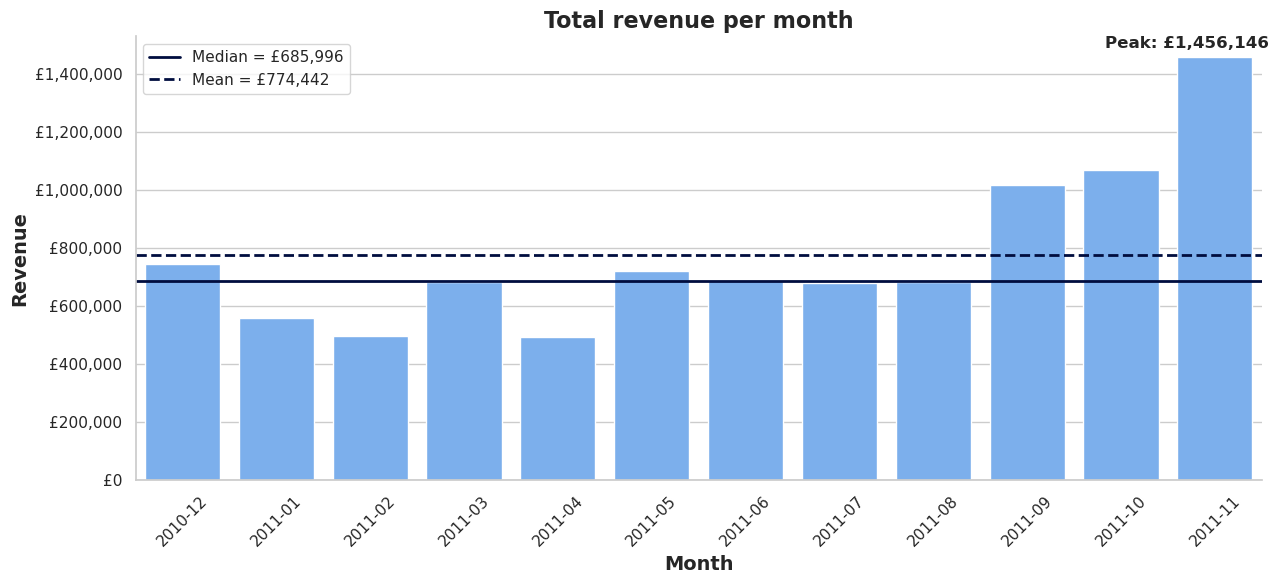

In [122]:
revenue_per_month = (
    df_cleaned.set_index("InvoiceDate")["Revenue"]
    .resample("M")
    .sum()
    .reset_index()
)

# for easier x-axis
revenue_per_month["YearMonth"] = revenue_per_month["InvoiceDate"].dt.strftime("%Y-%m")

# last month is incomplete, so I removed it
revenue_per_month = revenue_per_month[revenue_per_month["YearMonth"] != "2011-12"]

# for mean and median
mean_val = revenue_per_month["Revenue"].mean()
median_val = revenue_per_month["Revenue"].median()

# finding month and revenue for peak
peak_idx = revenue_per_month["Revenue"].idxmax()
peak_month = revenue_per_month.loc[peak_idx, "YearMonth"]
peak = revenue_per_month.loc[peak_idx, "Revenue"]

# creating bar chart
plt.figure(figsize=(13, 6))

ax = sns.barplot(
    data=revenue_per_month,
    x="YearMonth",
    y="Revenue",
    color=BRAND_BLUE
)

# horizontal line for median
ax.axhline(
    median_val,
    linestyle="solid",
    linewidth=2,
    color=TEXT_NAVY,
    label=f"Median = £{median_val:,.0f}"
)

# horizontal line for mean
ax.axhline(
    mean_val,
    linestyle="dashed",
    linewidth=2,
    color=TEXT_NAVY,
    label=f"Mean = £{mean_val:,.0f}"
)

# annotating bar with peak
peak_x = list(revenue_per_month["YearMonth"]).index(peak_month)
ax.annotate(
    f"Peak: £{peak:,.0f}",
    xy=(peak_x, peak),
    xytext=(-20, 7),
    textcoords="offset points",
    ha="center",
    fontsize=12,
    weight="bold"
)

ax.set_title("Total revenue per month", fontsize=16, weight="bold")
ax.set_xlabel("Month", fontsize=14, weight="bold")
ax.set_ylabel("Revenue", fontsize=14, weight="bold")

# formatting y-axis
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("£{x:,.0f}"))

plt.xticks(rotation=45)
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

### Top 10 products

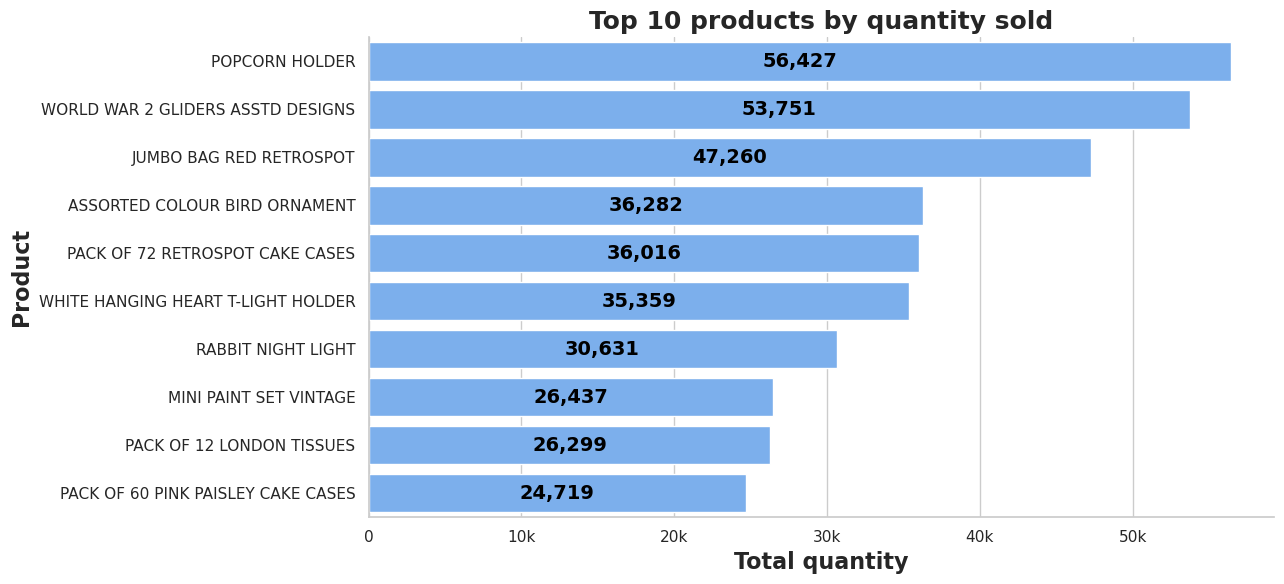

In [124]:
def format_thousands(x, pos):
    if x >= 1_000:
        return f"{x/1_000:.0f}k"
    return f"{x:.0f}"

# finding top 10 most sold products 
most_sold = (
    df_products.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(13, 6))

horizontal_bar = sns.barplot(
    data=most_sold,
    x="Quantity",
    y="Description",
    color=BRAND_BLUE
)

horizontal_bar.set_title("Top 10 products by quantity sold", fontsize=18, weight="bold")
horizontal_bar.set_xlabel("Total quantity", fontsize=16, weight="bold")
horizontal_bar.set_ylabel("Product", fontsize=16, weight="bold")

# formating values on x-axis
horizontal_bar.xaxis.set_major_formatter(FuncFormatter(format_thousands))

# adding and formating labels inside bars
for container in horizontal_bar.containers:
    horizontal_bar.bar_label(
        container,
        labels=[f"{v:,.0f}" for v in container.datavalues],
        label_type="center",
        padding=0,
        fontsize=14,
        fontweight="bold",
        color = "black"
    )

sns.despine()
plt.tight_layout()
plt.show()

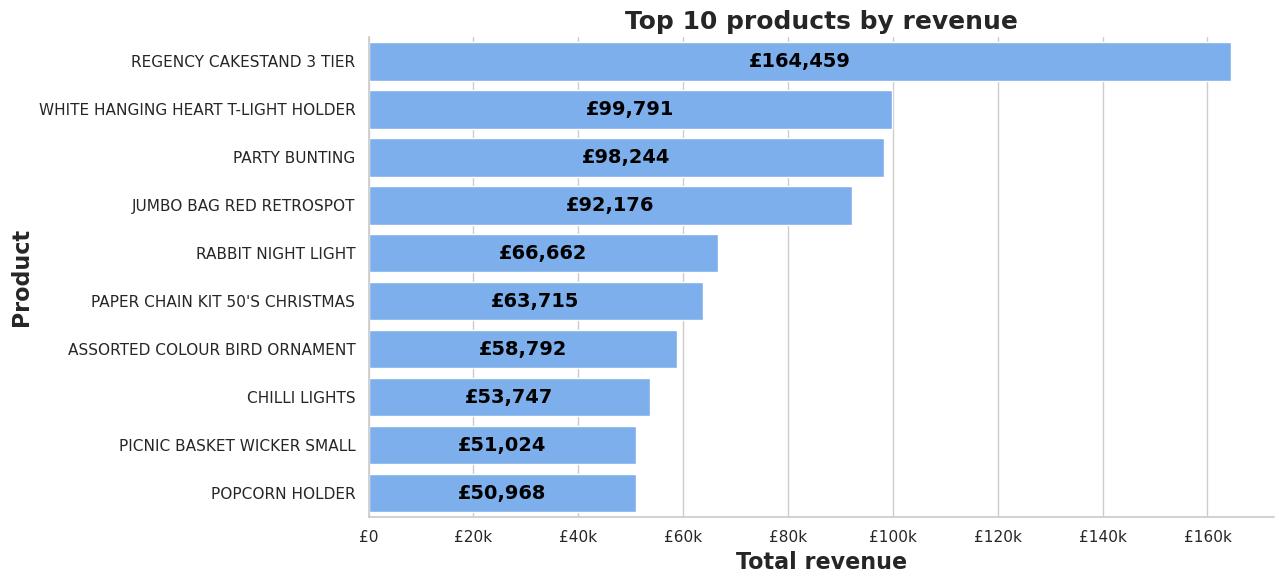

In [125]:
def format_currency(x, pos):
    if x >= 1_000_000:
        return f"£{x/1_000_000:.1f}M"
    if x >= 1_000:
        return f"£{x/1_000:.0f}k"
    return f"£{x:.0f}"

# finding top 10 highest-revenue products
top10_rev = (
    df_products.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(13, 6))

# creating bar chart
revenue_bar = sns.barplot(
    data=top10_rev,
    x="Revenue",
    y="Description",
    color=BRAND_BLUE
)

revenue_bar.set_title("Top 10 products by revenue", fontsize=18, weight="bold")
revenue_bar.set_xlabel("Total revenue", fontsize=16, weight="bold")
revenue_bar.set_ylabel("Product", fontsize=16, weight="bold")

# formating values on x-axis
revenue_bar.xaxis.set_major_formatter(FuncFormatter(format_currency))

# adding and formating labels inside bars
for container in revenue_bar.containers:
    revenue_bar.bar_label(
        container,
        labels=[f"£{v:,.0f}" for v in container.datavalues],
        label_type="center",
        padding=0,
        fontsize=14,
        fontweight="bold",
        color="black"
    )

sns.despine()
plt.tight_layout()
plt.show()

### Heatmaps by day of week 

In [127]:
df_heatmaps = df_products[
    (df_products["Quantity"] >= 0) &
    (df_products["IsReturn"] == False)
].copy()

# ordering days and months
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
month_order = [ "January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

# make them categories
df_heatmaps["DayOfWeek"] = pd.Categorical(df_heatmaps["DayOfWeek"], categories=weekday_order, ordered=True)
df_heatmaps["MonthName"] = pd.Categorical(df_heatmaps["MonthName"], categories=month_order, ordered=True)

revenue_data = (
    df_heatmaps.groupby(["DayOfWeek", "MonthName"])["Revenue"]
    .sum()
    .unstack()
    .fillna(0)
)

quantity_data = (
    df_heatmaps.groupby(["DayOfWeek", "MonthName"])["Quantity"]
    .sum()
    .unstack()
    .fillna(0)
)

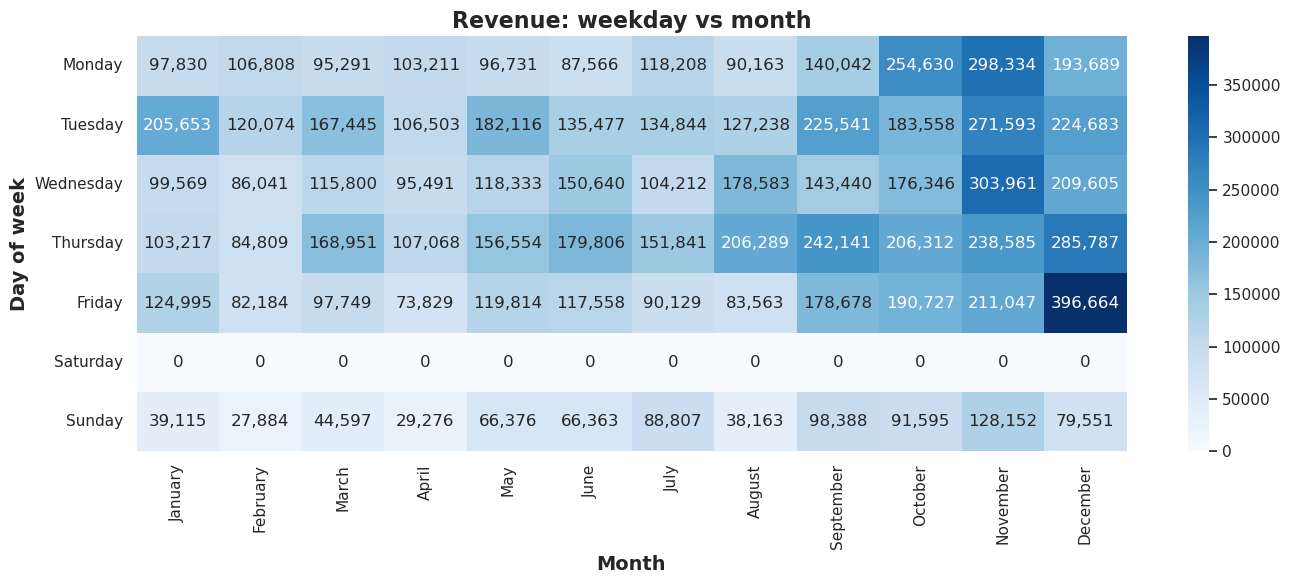

In [128]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    revenue_data,
    cmap="Blues",
    annot=True,
    fmt=",.0f"
)

plt.title("Revenue: weekday vs month", fontsize=16, weight="bold")
plt.xlabel("Month", fontsize=14, weight="bold")
plt.ylabel("Day of week", fontsize=14, weight="bold")

plt.tight_layout()
plt.show()

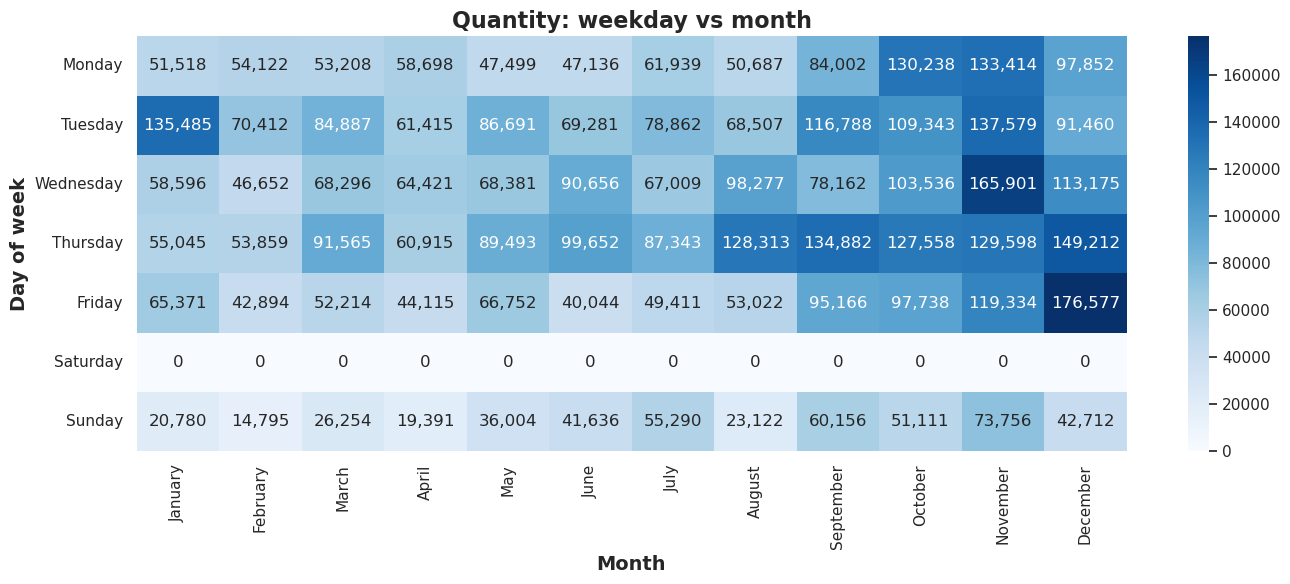

In [129]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    quantity_data,
    cmap="Blues",
    annot=True,
    fmt=",.0f"
)

plt.title("Quantity: weekday vs month", fontsize=16, weight="bold")
plt.xlabel("Month", fontsize=14, weight="bold")
plt.ylabel("Day of week", fontsize=14, weight="bold")

plt.tight_layout()
plt.show()

### Heatmaps by hour of day 

In [131]:
revenue_data = (
    df_heatmaps.groupby(["DayOfWeek", "Hour"])["Revenue"]
    .sum()
    .unstack()
    .fillna(0)
)

quantity_data = (
    df_heatmaps.groupby(["DayOfWeek", "Hour"])["Quantity"]
    .sum()
    .unstack()
    .fillna(0)
)

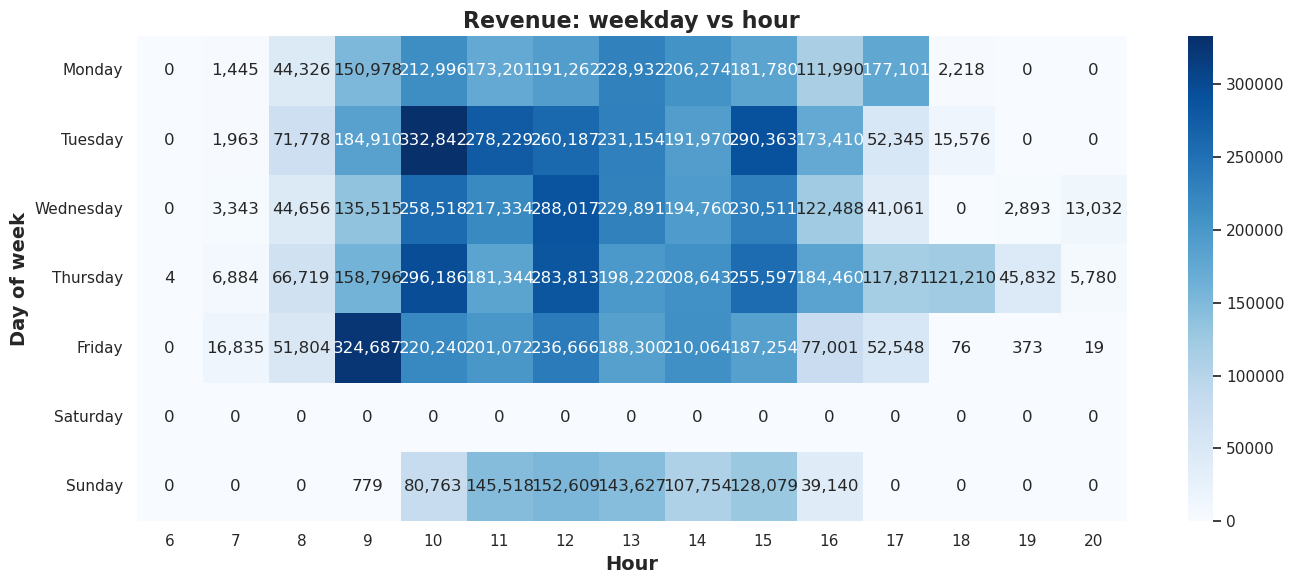

In [132]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    revenue_data,
    cmap="Blues",
    annot=True,
    fmt=",.0f"
)

plt.title("Revenue: weekday vs hour", fontsize=16, weight="bold")
plt.xlabel("Hour", fontsize=14, weight="bold")
plt.ylabel("Day of week", fontsize=14, weight="bold")

plt.tight_layout()
plt.show()

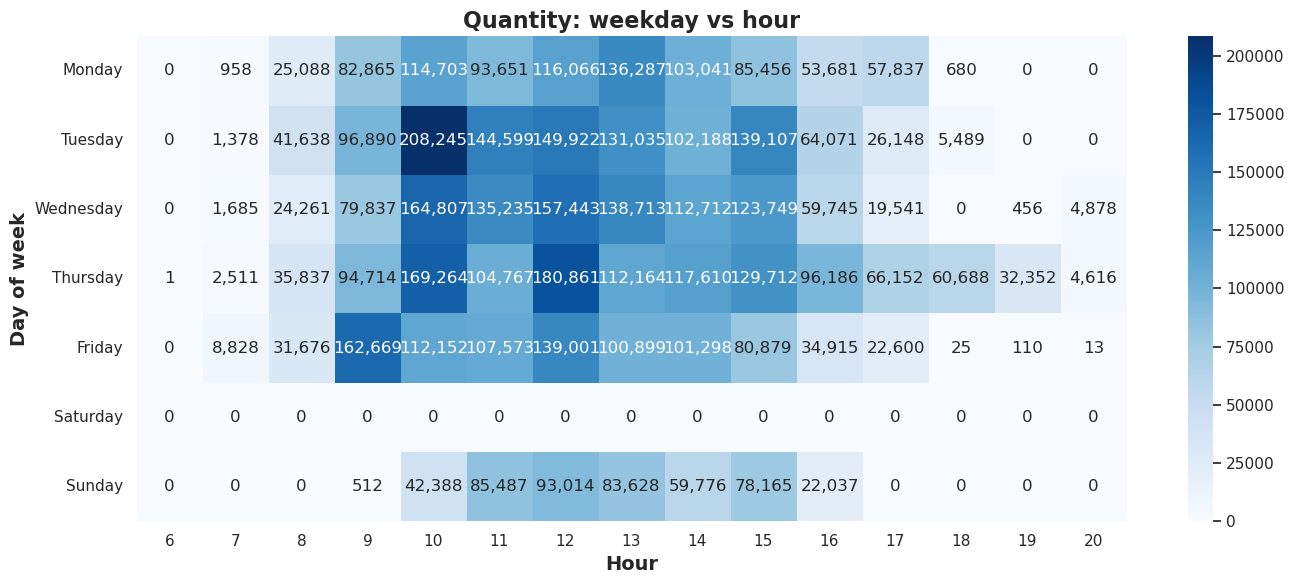

In [133]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    quantity_data,
    cmap="Blues",
    annot=True,
    fmt=",.0f"
)

plt.title("Quantity: weekday vs hour", fontsize=16, weight="bold")
plt.xlabel("Hour", fontsize=14, weight="bold")
plt.ylabel("Day of week", fontsize=14, weight="bold")

plt.tight_layout()
plt.show()

### Lifetime of cancelled/returned items

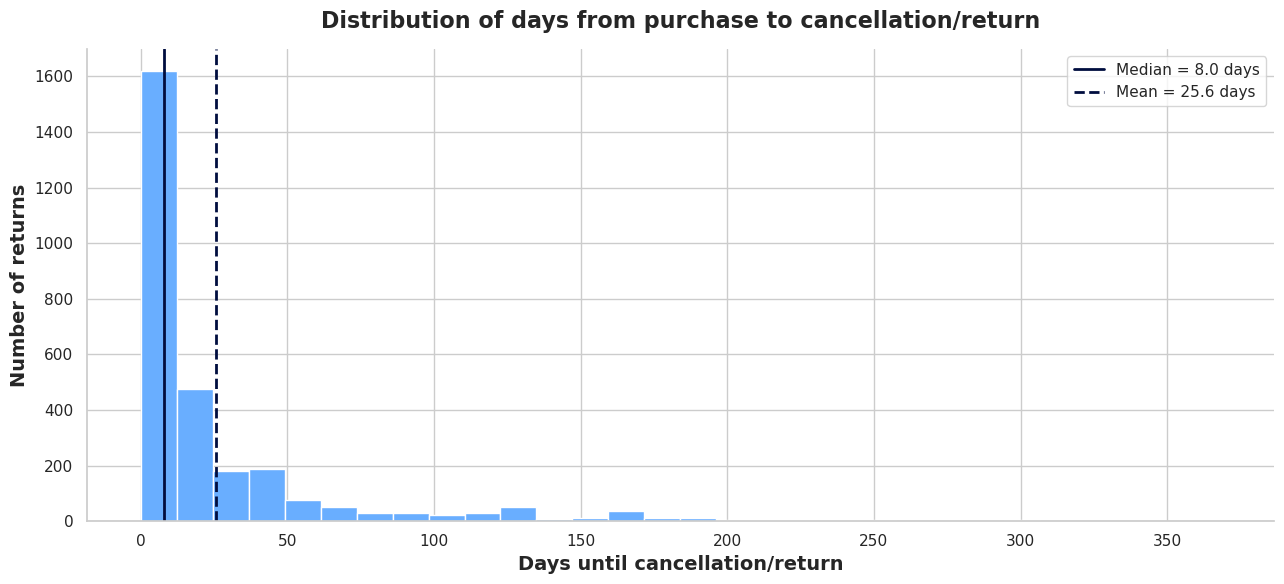

In [135]:
sales = df_products[~df_products["IsReturn"]].copy()

returns = df_products[df_products["IsReturn"]].copy()

returns["Quantity_abs"] = returns["Quantity"].abs()

# merging data and matching on CustomerID, StockCode and Quantity
matched = pd.merge(
    returns, 
    sales, 
    left_on=['CustomerID', 'Description', 'UnitPrice', 'StockCode', 'Country', 'Quantity_abs'],
    right_on=['CustomerID', 'Description', 'UnitPrice', 'StockCode', 'Country', 'Quantity'],
    suffixes=('_ret', '_sale')
)

matched = matched[matched["InvoiceDate_ret"] > matched["InvoiceDate_sale"]]
matched = matched.sort_values("InvoiceDate_sale")

matched = matched.drop_duplicates(
    subset=["CustomerID", "StockCode", "Quantity_abs", "InvoiceDate_ret"],
    keep="last"
)

matched['Lifetime_days'] = (matched['InvoiceDate_ret'] - matched['InvoiceDate_sale']).dt.days

mean_lifespan = matched['Lifetime_days'].mean()
median_lifespan = matched['Lifetime_days'].median()

plt.figure(figsize=(13, 6))

ax = sns.histplot(
    matched['Lifetime_days'], 
    bins=30, 
    color=BRAND_BLUE, 
    alpha=1.0
)

# adding median
ax.axvline(
    median_lifespan, 
    linestyle="solid", 
    linewidth=2, 
    color=TEXT_NAVY, 
    label=f"Median = {median_lifespan:.1f} days"
)

# adding mean
ax.axvline(
    mean_lifespan, 
    linestyle="dashed", 
    linewidth=2, 
    color=TEXT_NAVY, 
    label=f"Mean = {mean_lifespan:.1f} days"
)

ax.set_title("Distribution of days from purchase to cancellation/return", fontsize=16, weight="bold", pad=15)
ax.set_xlabel("Days until cancellation/return", fontsize=14, weight="bold")
ax.set_ylabel("Number of returns", fontsize=14, weight="bold")

plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

In [136]:
matched[['CustomerID','StockCode','Quantity_abs']].duplicated().sum()

66

In [137]:
matched[["CustomerID", "StockCode", "Quantity_abs", "InvoiceDate_ret"]].duplicated().sum()

0

In [138]:
len(returns), len(matched)

(8666, 2863)

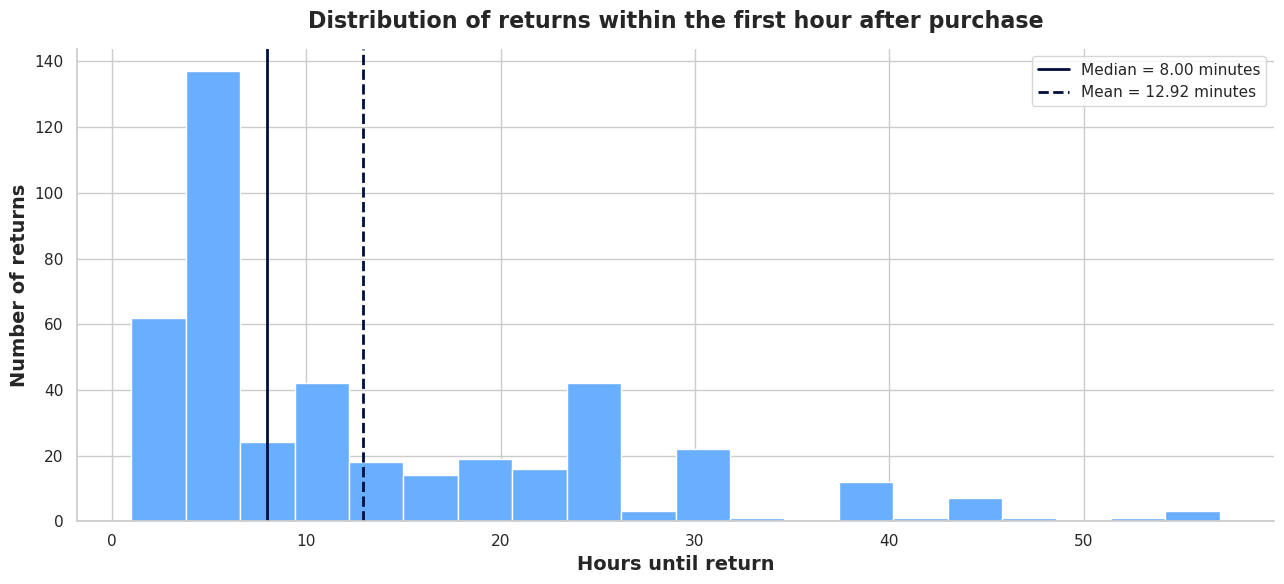

In [139]:
matched["Lifetime_days_hours"] = (
    matched["InvoiceDate_ret"] - matched["InvoiceDate_sale"]
).dt.total_seconds() / 60

# keep only returns within first hour
first_hour_returns = matched[matched["Lifetime_days_hours"] <= 60].copy()

mean_hours = first_hour_returns["Lifetime_days_hours"].mean()
median_hours = first_hour_returns["Lifetime_days_hours"].median()

plt.figure(figsize=(13, 6))

ax = sns.histplot(
    first_hour_returns["Lifetime_days_hours"],
    bins=20,
    color=BRAND_BLUE,
    alpha=1.0
)

ax.axvline(
    median_hours,
    linestyle="solid",
    linewidth=2,
    color=TEXT_NAVY,
    label=f"Median = {median_hours:.2f} minutes"
)

ax.axvline(
    mean_hours,
    linestyle="dashed",
    linewidth=2,
    color=TEXT_NAVY,
    label=f"Mean = {mean_hours:.2f} minutes"
)

ax.set_title("Distribution of returns within the first hour after purchase", fontsize=16, weight="bold", pad=15)
ax.set_xlabel("Hours until return", fontsize=14, weight="bold")
ax.set_ylabel("Number of returns", fontsize=14, weight="bold")

plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

## RFM analysis

In [141]:
rfm_df = df_products[
    (df_products["CustomerID"].notna()) &
    (df_products["Quantity"] > 0) &
    (df_products["UnitPrice"] > 0)
].copy()

### Calculating key metrics for each customer

In [143]:
reference_date = rfm_df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [144]:
rfm = rfm_df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Revenue": "sum"
}).reset_index()

rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

In [145]:
rfm["R_score"] = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 5, labels=[1,2,3,4,5])

In [146]:
rfm["RFM_score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

In [147]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
0,12346.00,326,1,77183.60,1,1,5,115
1,12347.00,2,7,4310.00,5,5,5,555
2,12348.00,75,4,1437.24,2,4,4,244
3,12349.00,19,1,1457.55,4,1,4,414
4,12350.00,310,1,294.40,1,1,2,112


In [148]:
rfm["R_score"] = rfm["R_score"].astype(int)
rfm["F_score"] = rfm["F_score"].astype(int)
rfm["M_score"] = rfm["M_score"].astype(int)

### Segregating cutomers into segments

In [150]:
def rfm_segment(row):
    if row["R_score"] >= 4 and row["F_score"] >= 4 and row["M_score"] >= 4:
        return "Champions"
    
    elif row["R_score"] >= 4 and row["F_score"] >= 3:
        return "Loyal customers"
    
    elif row["R_score"] >= 4 and row["F_score"] <= 2:
        return "New customers"
    
    elif row["R_score"] >= 3 and row["F_score"] >= 3 and row["M_score"] >= 3:
        return "Potential loyalists"
    
    elif row["R_score"] <= 2 and row["F_score"] >= 3:
        return "At risk"
    
    elif row["R_score"] <= 2 and row["F_score"] <= 2 and row["M_score"] >= 3:
        return "Cannot lose them"
    
    elif row["R_score"] <= 2 and row["F_score"] <= 2:
        return "Lost customers"
    
    else:
        return "Others"

rfm["Segment"] = rfm.apply(rfm_segment, axis=1)

In [151]:
rfm["Segment"].value_counts()

Segment
Champions              956
Lost customers         827
At risk                637
Loyal customers        494
Others                 433
Potential loyalists    427
New customers          319
Cannot lose them       241
Name: count, dtype: int64

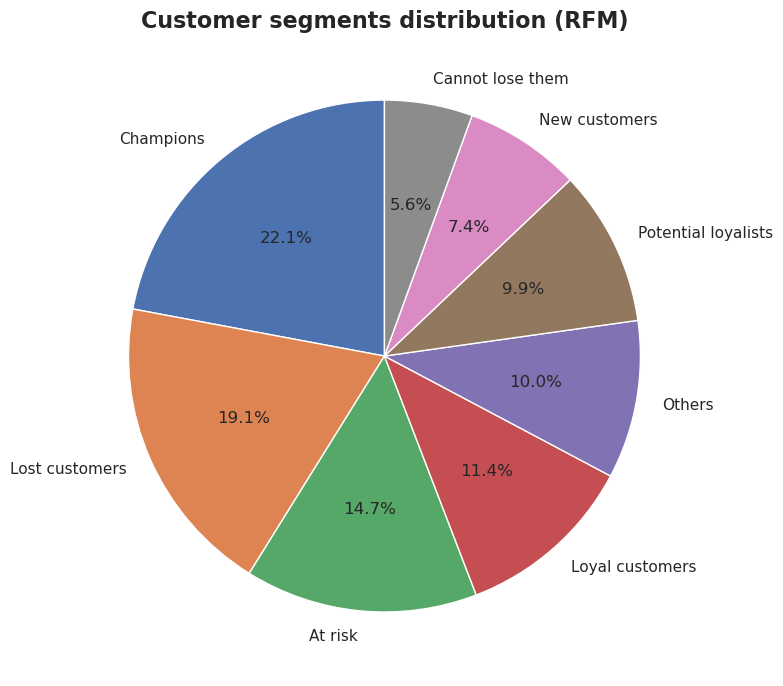

In [152]:
segment_counts = rfm["Segment"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    segment_counts,
    labels=segment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer segments distribution (RFM)", fontsize=16, weight="bold")

plt.tight_layout()
plt.show()

In [153]:
segments_info = (
    rfm.merge(
        rfm_df[["CustomerID", "InvoiceNo"]],
        on="CustomerID",
        how="left"
    )
    .groupby("Segment")
    .agg(
        Clients=("CustomerID", "nunique"),
        Orders=("InvoiceNo", "nunique"),
        TotalRevenue=("Monetary", "sum"),
        AvgRecency=("Recency", "mean"),
        AvgFrequency=("Frequency", "mean"),
        AvgMonetary=("Monetary", "mean")
    )
    .reset_index()
)

In [154]:
segments_info["TotalRevenue"] = segments_info["TotalRevenue"].map("£{:,.0f}".format)
segments_info["AvgMonetary"] = segments_info["AvgMonetary"].map("£{:,.0f}".format)
segments_info["AvgRecency"] = segments_info["AvgRecency"].round(1)
segments_info["AvgFrequency"] = segments_info["AvgFrequency"].round(1)

total_revenue = rfm["Monetary"].sum()
segments_info["RevenueShare"] = (
    rfm.groupby("Segment")["Monetary"].sum() / total_revenue
).values

segments_info["RevenueShare"] = segments_info["RevenueShare"].map("{:.1%}".format)

In [155]:
segment_order = [
    "Champions",
    "Loyal customers",
    "Potential loyalists",
    "New customers",
    "Cannot lose them",
    "At risk",
    "Lost customers",
    "Others"
]

segments_info["Segment"] = pd.Categorical(
    segments_info["Segment"],
    categories=segment_order,
    ordered=True
)

segments_info = segments_info.sort_values("Segment")

In [156]:
display(segments_info)

,Segment,Clients,Orders,TotalRevenue,AvgRecency,AvgFrequency,AvgMonetary,RevenueShare
2,Champions,956,10563,"£4,129,115,827",10.20,28.90,"£17,817",65.3%
4,Loyal customers,494,1458,"£28,638,089",16.20,3.20,£923,6.0%
7,Potential loyalists,427,2055,"£129,109,969",50.10,6.10,"£2,879",10.1%
5,New customers,319,394,"£6,777,977",17.70,1.30,£677,1.6%
1,Cannot lose them,241,309,"£11,367,228",182.30,1.30,"£1,215",3.7%
0,At risk,637,2158,"£62,426,344",143.80,4.40,"£1,671",9.0%
3,Lost customers,827,864,"£3,574,839",228.50,1.00,£265,2.1%
6,Others,433,601,"£8,680,396",52.80,1.50,£656,2.1%


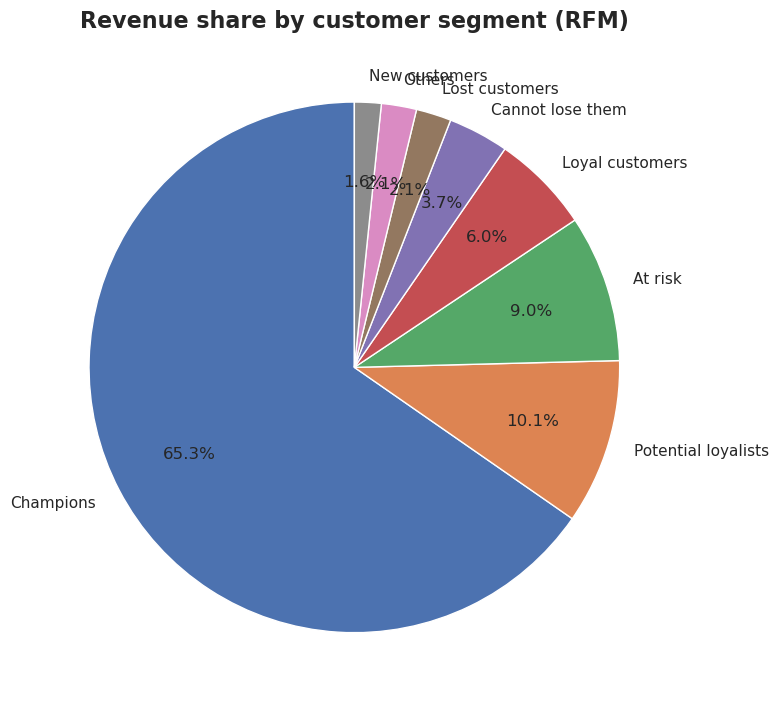

In [157]:
segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 8))

plt.pie(
    segment_revenue,
    labels=segment_revenue.index,
    autopct="%1.1f%%",
    startangle=90,
    labeldistance=1.1,
    pctdistance=0.7,
    wedgeprops={"edgecolor": "white"}
)

plt.title("Revenue share by customer segment (RFM)", fontsize=16, weight="bold")

plt.tight_layout()
plt.show()

In [158]:
rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]].mean()

,Recency,Frequency,Monetary
Segment,,,
At risk,152.90,3.39,1229.23
Cannot lose them,185.58,1.28,1340.19
Champions,12.81,11.05,5970.77
Lost customers,227.90,1.04,226.26
Loyal customers,16.12,2.95,1065.08
New customers,18.55,1.24,445.99
Others,53.61,1.39,431.43
Potential loyalists,51.13,4.81,2059.71


In [159]:
rfm[["Recency", "Frequency", "Monetary"]].corr()

,Recency,Frequency,Monetary
Recency,1.00,-0.26,-0.12
Frequency,-0.26,1.00,0.55
Monetary,-0.12,0.55,1.00


## References
1. Carrie. *E-commerce Data*. https://www.kaggle.com/datasets/carrie1/ecommerce-data
2. Moreno, A. I. (2025, September 23). *Is This Really a Jupyter Notebook? — Customizing Jupyter Notebook Appearance with CSS*. Medium; Data Science Collective. https://medium.com/data-science-collective/this-is-really-a-jupyter-notebook-customizing-jupyter-notebook-appearance-with-css-b04d71ccd0a8
3. *pandas.DataFrame.to_html — pandas 3.0.1 documentation*. Pandas. https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_html.html
4. *Module: display — IPython 9.11.0 documentation*. IPython. https://ipython.readthedocs.io/en/stable/api/generated/IPython.display.html
5. *matplotlib.pyplot.axhline — Matplotlib 3.10.8 documentation*. Matplotlib. https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axhline.html
6. *matplotlib.pyplot.axvline — Matplotlib 3.10.8 documentation*. Matplotlib. https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axvline.html
7. *matplotlib.axes.Axes.annotate — Matplotlib 3.10.8 documentation*. Matplotlib. https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.annotate.html
8. *matplotlib.axis.Axis.set_major_formatter — Matplotlib 3.10.8 documentation*. Matplotlib. https://matplotlib.org/stable/api/_as_gen/matplotlib.axis.Axis.set_major_formatter.html
9. *seaborn.despine — seaborn 0.13.2 documentation*. Seaborn. https://seaborn.pydata.org/generated/seaborn.despine.html
10. Головин, Д. (2023, April 6). *Полезные методы работы с данными в Pandas. Часть 1*. Хабр. https://habr.com/ru/companies/otus/articles/727222/